# Libraries

In [1]:
import os
import logging
import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
import seaborn as sns
from pgmpy.models import DiscreteBayesianNetwork
from pgmpy.estimators import HillClimbSearch, TreeSearch, MaximumLikelihoodEstimator, BIC, ExpertKnowledge
from pgmpy.metrics.metrics import SHD
from pgmpy.inference import VariableElimination
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

In [2]:
np.random.seed(42)
logging.getLogger('pgmpy').setLevel(logging.ERROR)
os.makedirs("figures", exist_ok=True)

# Dataset Overview: Movies_Dataset.csv

### Context
This dataset provides a comprehensive look at the commercial and critical success of 2,855 movies (1990–2020). By merging three IMDb sources, it captures the intersection of creative attributes (genre, source) and financial outcomes (box office categories).  
### Data Sources:  
[IMDb Top 10000 Movies Dataset](https://www.kaggle.com/datasets/moazeldsokyx/imdb-top-10000-movies-dataset)  
[Complete IMDb Movies Dataset](https://www.kaggle.com/datasets/gorochu/complete-imdb-movies-dataset/data)  
[Movies Metrics, Features and Statistics Dataset](https://www.kaggle.com/datasets/michaelmatta0/movies-ultimate-metrics-features-and-metadata)  
### Data Dictionary

| Column Name | Brief Description | Categories Available |
| :--- | :--- | :--- |
| **genre** | Every genre is assigned to a column containing 'Yes' or 'No' values. | Drama, Action, Sci-Fi, Crime, Thriller, etc. |
| **certificate** | The age-based content rating. | G, PG, PG-13, R, others |
| **year** | The movie release specific timeframe. |  Before 1990s, 1990s, 2000-2005, 2005-2010, 2010-2015, 2015-2020 |
| **countries_published** | Count of countries where the movie was released. | One, Two, Three, Four, Five, More than 5 |
| **languages_published** | Count of languages the movie was released in. | One, Two, Three, Four, Five, More than 5 |
| **number_of_actors** | The binned range of the total cast size. | 1 to 5, 5 to 10, 10 to 15, 15 or more |
| **number_of_directors** | Total number of directors credited. | 1, 2, 3 |
| **source** | The original material the film is based on. | Original Screenplay, Fiction Book, Comic, Game, Remake, etc. |
| **production_method** | Technical method used to produce the film. | Live Action, Animation, Digital Animation, etc. |
| **creative_type** | The thematic style or creative genre. | Contemporary Fiction, Fantasy, Sci-Fi, Super Hero, etc. |
| **has_franchise** | Whether the film belongs to a movie franchise. | Yes, No |
| **rating** | The qualitative score category of the movie based on IMDB score. | Poor((0,5]), Below Average((5,6]), Average((6,7]), Above Average((7,8]), Good((8,10]) |
| **runtime** | The categorized duration of the film. | Short(0 to 90 mins), Average(90 to 150 mins), Long(More than 150 mins) |
| **DBO** | Domestic Box Office revenue range ($). | Below 10M, 10-25M, 25-50M, 50-75M, 75-100M, 100-125M, 125-150M, 150-200M, 200-300M, Above 300M |
| **IBO** | International Box Office revenue range ($). | Below 5M, 5-10M, 10-25M, 25-50M, 50-100M, 100-150M, 150-200M, 200-300M, 300-500M, Above 500M |
| **production_budget** | Total production budget range ($). | Below 5M, 5-10M, 10-25M, 25-50M, 50-75M, 75-100M, 100-150M, 150-200M, Above 200M |

In the first step the dataset in imported and from all the genres available only most 6 frequent genres are included to have a better network structure diagram and more understandable and controled network.

In [3]:
df = pd.read_csv('Movies_dataset.csv')

columns = ['certificate', 'year', 'countries_published', 'languages_published',
       'number_of_actors', 'number_of_directors', 'source', 'IBO',
       'production_method', 'has_franchise', 'rating', 'runtime',
       'production_budget', 'action', 'adventure', 'comedy',
       'romance', 'drama', 'thriller', 'DBO']

data = df[columns]

# Cunstructing Network Structure

### Hill Climb Search
This strategy performs local hill climb search to estimates the DAG structure that has optimal score, according to the scoring method supplied(which is BIC in this case). Starts at model start_dag and proceeds by step-by-step network modifications until a local maximum is reached. Only estimates network structure, no parametrization. The scoring method considered in this case is BIC (Bayesian Information Criterion) given the formula : 
$$BIC = \ln(L) - \frac{k}{2} \ln(n)$$

**Where:**
* **$\ln(L)$**: The log-likelihood of the observed data given the model (representing how well the model fits the data).
* **$k$**: The number of free parameters in the model (the complexity).
* **$n$**: The number of observations in the dataset (sample size).
* **$\ln(n)$**: The natural logarithm of the sample size. (Together with k/2 is penalty for complexity)  

Before executing the HC search some node connections are avoided because one of the objectives of the study is to find the best combination of variables in favore of movie revenue and IMDb score so that there shouldn't be any connection from these nodes to the other (direction wise) also the revenue indicators also should not be connected.

In [4]:
forbidden = []
for column in columns:
    if column not in ['IBO', 'DBO', 'rating']:
        forbidden.append(('IBO', column)),
        forbidden.append(('DBO', column)),
        forbidden.append(('rating', column))

forbidden = ExpertKnowledge(forbidden_edges=forbidden+[('IBO', 'DBO'), ('DBO', 'IBO'), ('rating', 'DBO'),
                                                        ('rating', 'IBO'), ('DBO', 'rating'), ('IBO', 'rating')])

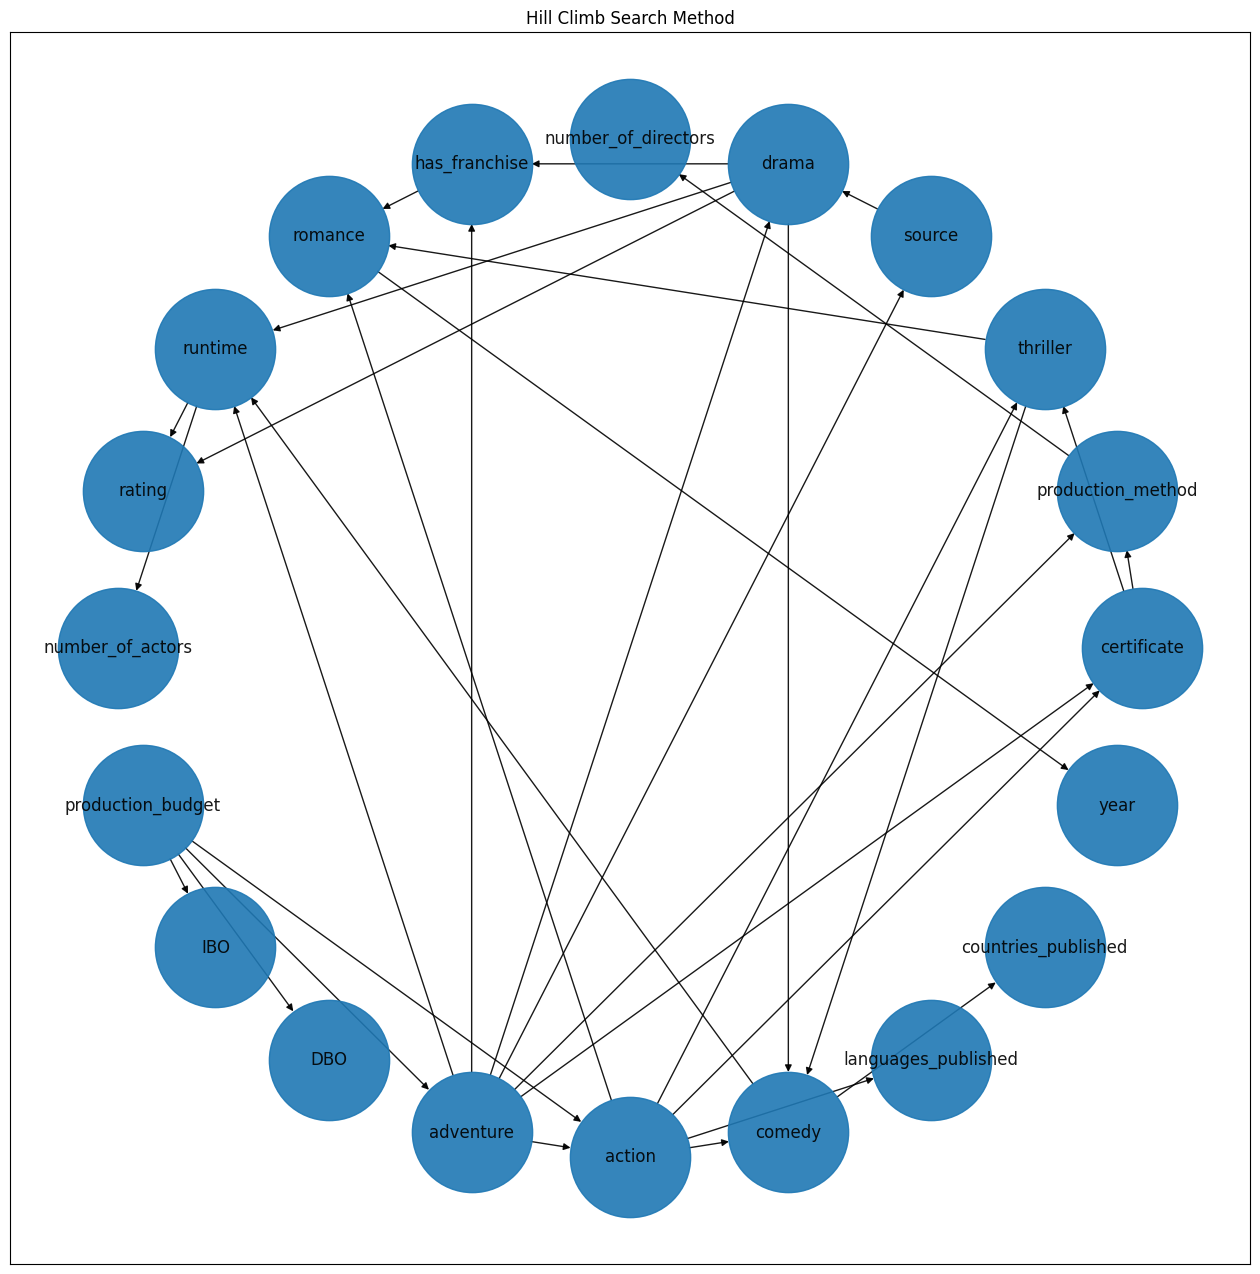

In [5]:
hc = HillClimbSearch(data)
hc_model = hc.estimate(scoring_method=BIC(data), show_progress=False, expert_knowledge=forbidden)

plt.figure(figsize=(16, 16))
G_hc = nx.DiGraph(hc_model.edges())
nx.draw_networkx(G_hc, pos=nx.circular_layout(G_hc), node_size=7500, alpha=0.9)
plt.title('Hill Climb Search Method')
plt.savefig("figures/Hill Climb Search Network Structure.png")
dbn_hc_model = DiscreteBayesianNetwork(hc_model.edges())

### Tree Search
In addition to score-based structure learning, a tree-structured Bayesian Network was learned using the Chow–Liu algorithm (unsupervised tree BN). This approach constructs the maximum-weight spanning tree with mutual information score as edge weights and avoids cycles. The mutual information among variables X , Y interprets as how much knowing X reduces uncertainty about Y. A higher mutual information shows a stronger dependency and the search tree is looking for the tree that maximizes total MI.  
In this algorithm it is not possible to avoide some connections as the previous method and eliminating the edges after producing the DAG may result in some nodes with zero connections as they may only have one connection in total.

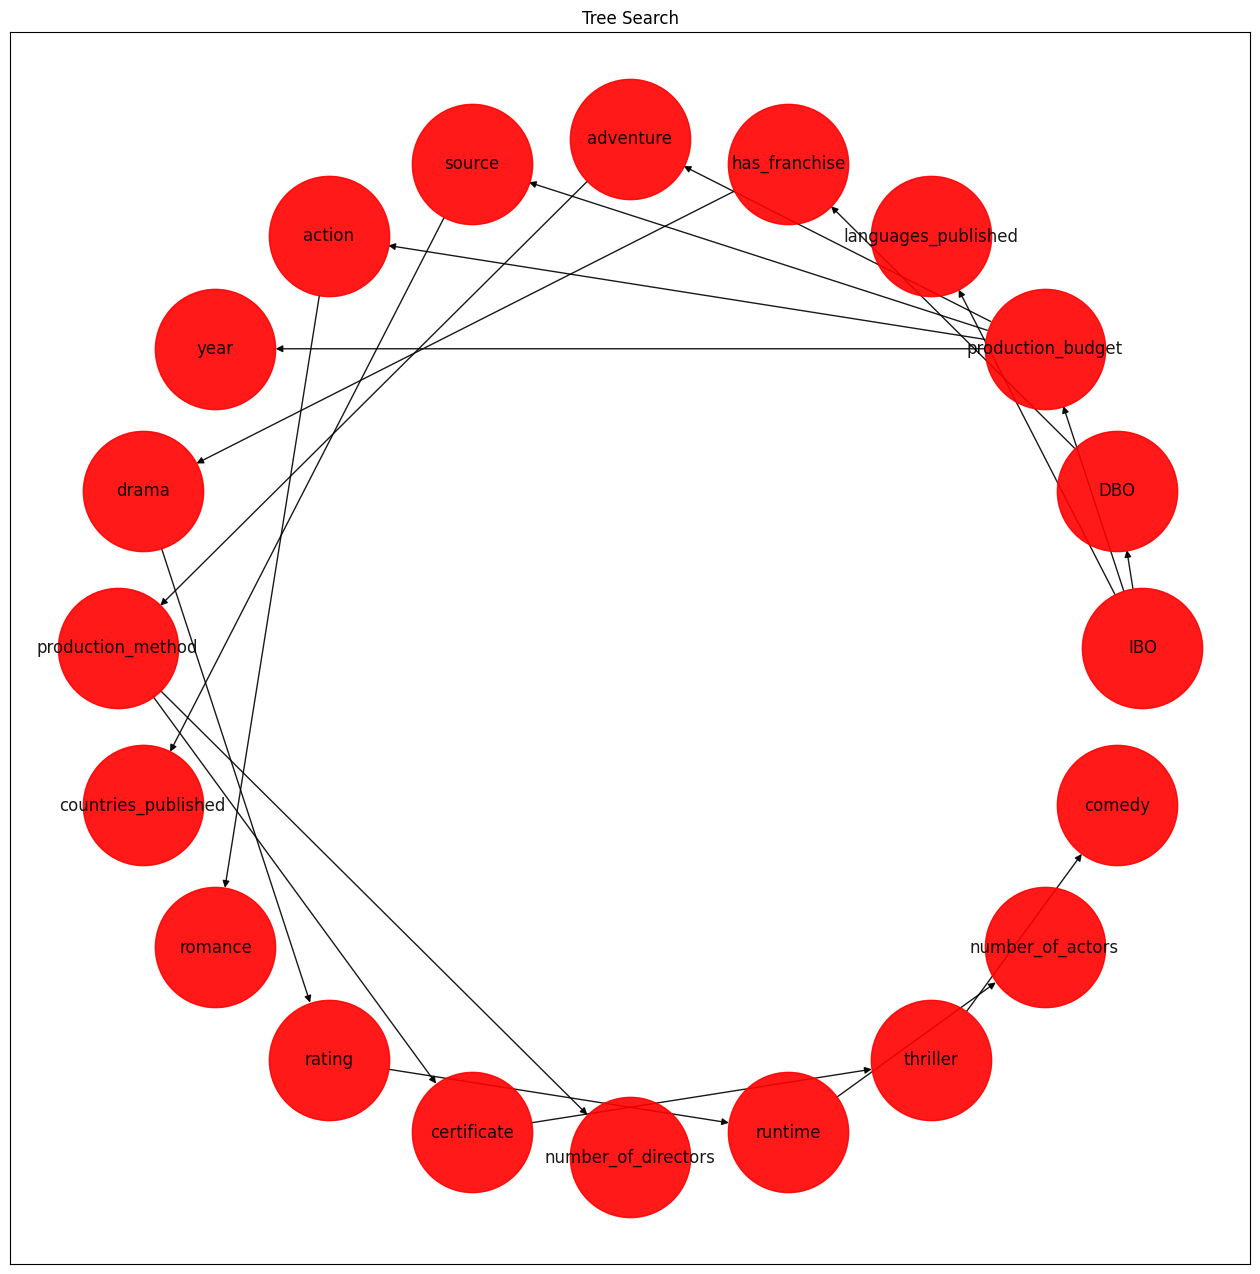

In [6]:
tree = TreeSearch(data)
tree_model = tree.estimate(estimator_type='chow-liu', show_progress=False)

plt.figure(figsize=(16, 16))
G_tree = nx.DiGraph(tree_model.edges())
nx.draw_networkx(G_tree, pos=nx.circular_layout(G_tree), node_size=7500, alpha=0.9, node_color='r')
plt.title('Tree Search')
plt.savefig("figures/Tree Search Network Structure.png")
dbn_tree_model = DiscreteBayesianNetwork(tree_model.edges())

Lastly a custom network is cunstructed as well to be compared with the other two networks cunstructed by Machine Learning techniques.

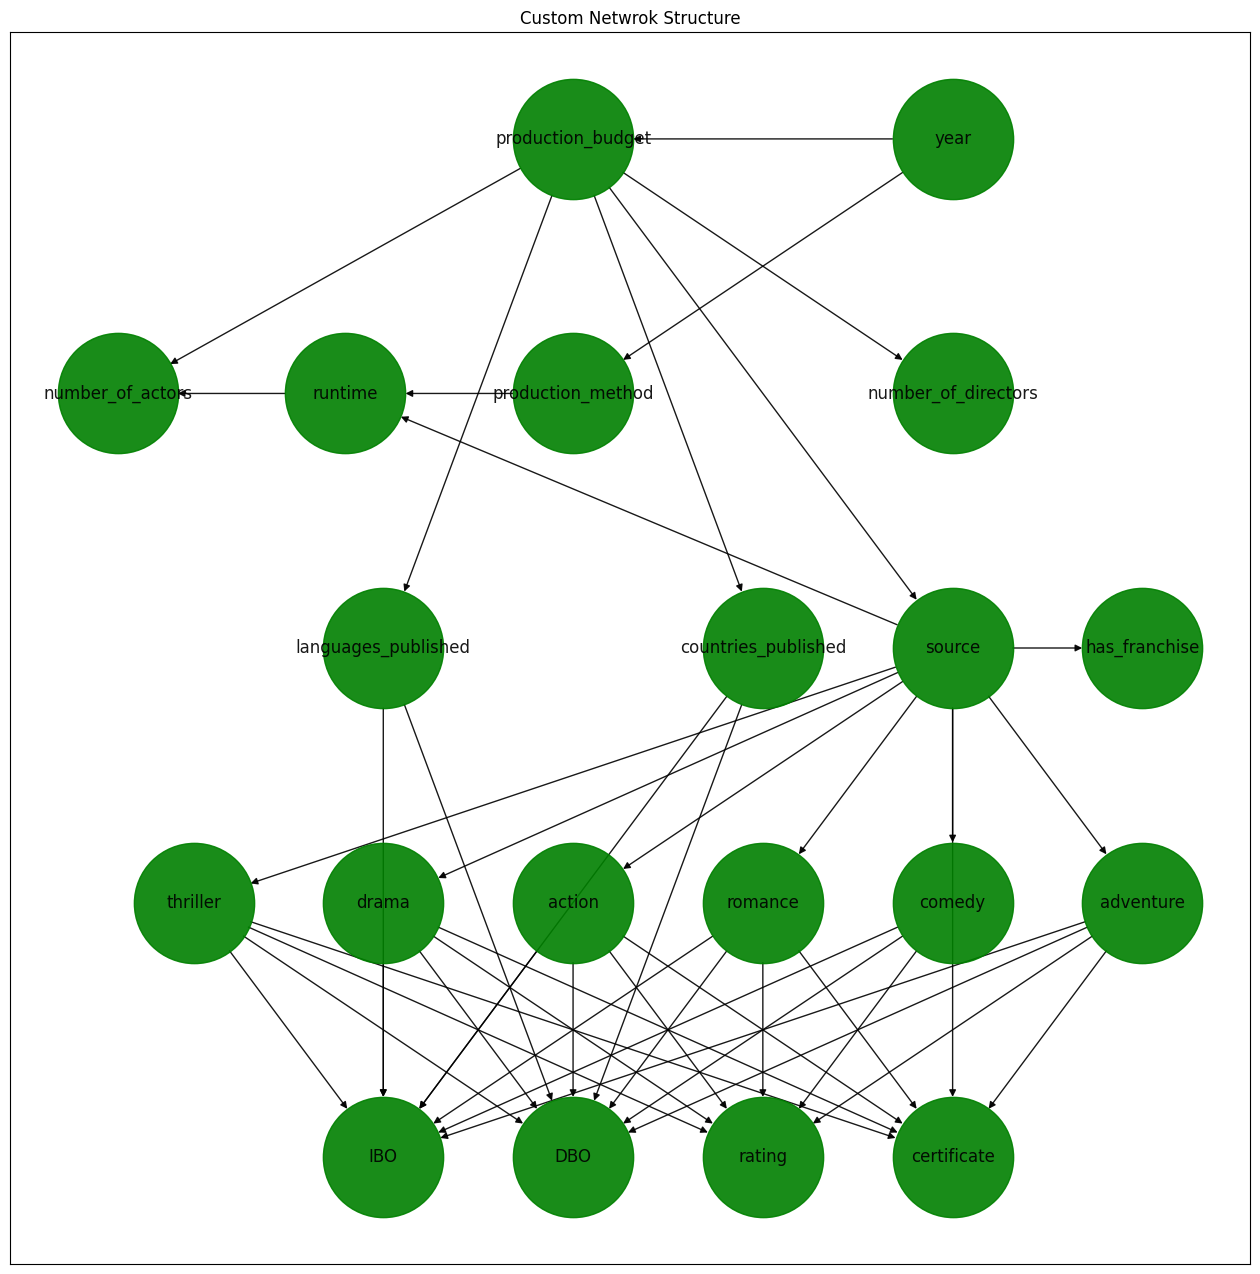

In [7]:
custom_edges = [('production_budget', 'number_of_directors'), ('production_budget', 'number_of_actors'),
                     ('production_budget', 'languages_published'), ('production_budget', 'countries_published'),
                     ('year', 'production_budget'), ('production_budget', 'source'),
                     ('languages_published', 'IBO'), ('languages_published', 'DBO'), ('countries_published', 'IBO'), 
                     ('countries_published', 'DBO'), ('runtime', 'number_of_actors'),
                     ('year', 'production_method'), ('thriller', 'IBO'), ('thriller', 'DBO'),
                     ('thriller', 'rating'), ('drama', 'IBO'), ('drama', 'DBO'), ('drama', 'rating'),
                     ('action', 'IBO'), ('action', 'DBO'), ('action', 'rating'), ('romance', 'IBO'), 
                     ('romance', 'DBO'), ('romance', 'rating'), ('comedy', 'IBO'), ('comedy', 'DBO'), 
                     ('comedy', 'rating'), ('adventure', 'DBO'), ('adventure', 'rating'), ('adventure', 'IBO'),
                     ('source', 'has_franchise'), ('production_method', 'runtime'), ('source', 'thriller'), ('source', 'drama'),
                     ('source', 'action'), ('source', 'runtime'), ('source', 'romance'), ('source', 'comedy'), 
                     ('source', 'adventure'), ('source', 'certificate'), ('drama', 'certificate'), ('action', 'certificate'),
                     ('romance', 'certificate'), ('adventure', 'certificate'), ('thriller', 'certificate')
]

pos = {'production_budget': [1, -0.5], 'year': [1.5, -0.5], 'number_of_directors':[1.5, -0.75], 'number_of_actors':[0.4, -0.75],
       'runtime': [0.7, -0.75], 'languages_published': [0.75, -1], 'countries_published': [1.25, -1], 'source':[1.5, -1],
       'production_method': [1, -0.75], 'thriller': [0.5, -1.25], 'drama': [0.75, -1.25], 'action': [1, -1.25], 'romance': [1.25, -1.25],
       'comedy': [1.5, -1.25], 'adventure': [1.75, -1.25], 'rating': [1.25, -1.5], 'IBO': [0.75, -1.5], 'DBO': [1, -1.5], 'rating': [1.25, -1.5],
       'has_franchise': [1.75, -1], 'certificate': [1.5, -1.5]
}

plt.figure(figsize=(16, 16))
G_custom = nx.DiGraph(custom_edges)
nx.draw_networkx(G_custom, pos=pos, node_size=7500, alpha=0.9, node_color='g')
plt.title('Custom Netwrok Structure')
plt.savefig("figures/Custom Netwrok Structure.png", dpi=600)
dbn_custom_model = DiscreteBayesianNetwork(custom_edges)

# Networks Evaulation
To compare the three above mentioned networks first I have tried to compare their complexity by the number of thier edges and printing the node name with highest degree which means which the highest number of connections with the other nodes in this case(can be considered as the most influential factor in every network). By observing the result we can see that HC has the complexity equal to __33__  being more complex than the tree search and less complex than the custom network designed. Moreover the Markov Blanket for the variables `rating` , `IBO` and `DBO` in each network is computed to understand knowing which variables they are independent of the other. 

In [8]:
hc_degree_dict = dict(hc_model.degree())
max_degree_hc = max(hc_degree_dict, key=lambda x: hc_degree_dict[x])
print(f"Number of edges in HC search are : {len(hc_model.edges())}")
print(f"Node with highest degrees is : {max_degree_hc}({hc_degree_dict[max_degree_hc]})")
print(f"Markov blanket for the rating category in HC search are {hc_model.get_markov_blanket('rating')}")
print(f"Markov blanket for the IBO in HC search are {hc_model.get_markov_blanket('IBO')}")
print(f"Markov blanket for the DBO in HC search are {hc_model.get_markov_blanket('DBO')}\n")

tree_degree_dict = dict(tree_model.degree())
max_degree_tree = max(tree_degree_dict, key=lambda x: tree_degree_dict[x])
print(f"Number of edges in Tree search are : {len(tree_model.edges())}")
print(f"Node with highest degrees is : {max_degree_tree}({tree_degree_dict[max_degree_tree]})")
print(f"Markov blanket for the rating category in Tree search are {tree_model.get_markov_blanket('rating')}")
print(f"Markov blanket for the IBO in Tree search are {tree_model.get_markov_blanket('IBO')}")
print(f"Markov blanket for the DBO in Tree search are {tree_model.get_markov_blanket('DBO')}\n")

custom_degree_dict = dict(dbn_custom_model.degree())
max_degree_custom = max(custom_degree_dict, key=lambda x: custom_degree_dict[x])
print(f"Number of edges in custom network are : {len(dbn_custom_model.edges())}")
print(f"Node with highest degrees is : {max_degree_custom}({custom_degree_dict[max_degree_custom]})")
print(f"Markov blanket for the rating category in custom network are {dbn_custom_model.get_markov_blanket('rating')}")
print(f"Markov blanket for the IBO in custom network are {dbn_custom_model.get_markov_blanket('IBO')}")
print(f"Markov blanket for the DBO in custom network are {dbn_custom_model.get_markov_blanket('DBO')}")

Number of edges in HC search are : 32
Node with highest degrees is : adventure(8)
Markov blanket for the rating category in HC search are ['runtime', 'drama']
Markov blanket for the IBO in HC search are ['production_budget']
Markov blanket for the DBO in HC search are ['production_budget']

Number of edges in Tree search are : 19
Node with highest degrees is : production_budget(5)
Markov blanket for the rating category in Tree search are ['runtime', 'drama']
Markov blanket for the IBO in Tree search are ['DBO', 'languages_published', 'production_budget']
Markov blanket for the DBO in Tree search are ['has_franchise', 'IBO']

Number of edges in custom network are : 45
Node with highest degrees is : source(10)
Markov blanket for the rating category in custom network are ['thriller', 'romance', 'comedy', 'drama', 'action', 'adventure']
Markov blanket for the IBO in custom network are ['thriller', 'romance', 'comedy', 'drama', 'action', 'countries_published', 'languages_published', 'advent

The Structural Hamming Distance of each pair of networks are computed to understand how different are the networks with their given number of edges and __20__ nodes. The number computed indicates the total number of basic operations (adding edges, removing edges, and reversing edges) are required to transform one graph to the other.

In [9]:
print(f"SHD for HC and Custom networks pair : {SHD(dbn_hc_model, dbn_custom_model)}")
print(f"SHD for Tree and Custom networks pair : {SHD(dbn_tree_model, dbn_custom_model)}")
print(f"SHD for HC and Tree networks pair : {SHD(dbn_hc_model, dbn_tree_model)}")

SHD for HC and Custom networks pair : 65
SHD for Tree and Custom networks pair : 55
SHD for HC and Tree networks pair : 29


# Target Variables Best Case
All the networks are fitted to data using a Maximum Likelihood estimator to find the best combination of the variables in the markov blanket of the three target valriables `rating` , `IBO` and `DBO` in favor of the best case senario for the target variable.

In [10]:
dbns = [dbn_hc_model.fit(data, estimator=MaximumLikelihoodEstimator),
        dbn_tree_model.fit(data, estimator=MaximumLikelihoodEstimator),
        dbn_custom_model.fit(data, estimator=MaximumLikelihoodEstimator)
]

infers = [VariableElimination(dbn_hc_model),
          VariableElimination(dbn_tree_model),
          VariableElimination(dbn_custom_model)
]

networks = ["HC", "Tree", "Custom"]

After finding the best combination of variables for the target value in every network based on thier markov blanket the maximum aposteriori probability is computed for the target variable given the evidences.

In [11]:
print("               ----- Variable combination in favor of rating='Good' based on rating markov blanket in the network' -----\n")

for dbn, infer, network in zip(dbns, infers, networks):
    map_rating = infer.map_query(
            variables=dbn.get_markov_blanket('rating'),
            evidence={'rating': 'Good'},
            show_progress=False
        )
    prob_map_rating = infer.query(
                variables=['rating'],
                evidence=map_rating
            )
    
    print(f"Based on the {network} network : {map_rating} \n {prob_map_rating} \n")


               ----- Variable combination in favor of rating='Good' based on rating markov blanket in the network' -----

Based on the HC network : {'runtime': 'Average', 'drama': 'Yes'} 
 +-----------------------+---------------+
| rating                |   phi(rating) |
+=======================+===============+
| rating(Above Average) |        0.3538 |
+-----------------------+---------------+
| rating(Average)       |        0.4465 |
+-----------------------+---------------+
| rating(Below Average) |        0.1435 |
+-----------------------+---------------+
| rating(Good)          |        0.0372 |
+-----------------------+---------------+
| rating(Poor)          |        0.0190 |
+-----------------------+---------------+ 

Based on the Tree network : {'runtime': 'Average', 'drama': 'Yes'} 
 +-----------------------+---------------+
| rating                |   phi(rating) |
+=======================+===============+
| rating(Above Average) |        0.3640 |
+-----------------------+-

In [12]:
print("               ----- Variable combination in favor of IBO='Above 500M' based on IBO markov blanket in the networks -----\n")

for dbn, infer, network in zip(dbns, infers, networks):
    map_IBO = infer.map_query(
            variables=dbn.get_markov_blanket('IBO'),
            evidence={'IBO': 'Above 500 Million($)'},
            show_progress=False
        )
    prob_map_IBO = infer.query(
                variables=['IBO'],
                evidence=map_IBO
            )
    
    print(f"Based on the {network} network : {map_IBO} \n {prob_map_IBO} \n")

               ----- Variable combination in favor of IBO='Above 500M' based on IBO markov blanket in the networks -----

Based on the HC network : {'production_budget': '150 to 200 Million($)'} 
 +----------------------------+------------+
| IBO                        |   phi(IBO) |
+============================+============+
| IBO(10 to 25 Million($))   |     0.0000 |
+----------------------------+------------+
| IBO(100 to 150 Million($)) |     0.0472 |
+----------------------------+------------+
| IBO(150 to 200 Million($)) |     0.0472 |
+----------------------------+------------+
| IBO(200 to 300 Million($)) |     0.1792 |
+----------------------------+------------+
| IBO(25 to 50 Million($))   |     0.0000 |
+----------------------------+------------+
| IBO(300 to 500 Million($)) |     0.2642 |
+----------------------------+------------+
| IBO(5 to 10 Million($))    |     0.0000 |
+----------------------------+------------+
| IBO(50 to 100 Million($))  |     0.0189 |
+----------

In [13]:
print("               ----- Variable combination in favor of DBO='Above 500M' based on DBO markov blanket in the networks -----\n")

for dbn, infer, network in zip(dbns, infers, networks):
    map_DBO = infer.map_query(
            variables=dbn.get_markov_blanket('DBO'),
            evidence={'DBO': 'Above 300 Million($)'},
            show_progress=False
        )
    prob_map_DBO = infer.query(
                variables=['DBO'],
                evidence=map_DBO
            )
    
    print(f"Based on the {network} network : {map_DBO} \n {prob_map_DBO} \n")

               ----- Variable combination in favor of DBO='Above 500M' based on DBO markov blanket in the networks -----

Based on the HC network : {'production_budget': '150 to 200 Million($)'} 
 +----------------------------+------------+
| DBO                        |   phi(DBO) |
+============================+============+
| DBO(10 to 25 Million($))   |     0.0000 |
+----------------------------+------------+
| DBO(100 to 125 Million($)) |     0.1132 |
+----------------------------+------------+
| DBO(125 to 150 Million($)) |     0.0755 |
+----------------------------+------------+
| DBO(150 to 200 Million($)) |     0.1415 |
+----------------------------+------------+
| DBO(200 to 300 Million($)) |     0.1981 |
+----------------------------+------------+
| DBO(25 to 50 Million($))   |     0.0566 |
+----------------------------+------------+
| DBO(50 to 75 Million($))   |     0.0660 |
+----------------------------+------------+
| DBO(75 to 100 Million($))  |     0.0660 |
+----------

Finally both the `DBO` and `rating` are targeted at the same time and checking the maximum aposteriori probabilities results, it is interesting to observe that given their best category combination of their Markov Blankets a movie having a `rating=Average` and `DBO=Above 300 Million($)` is more probable using the HC and Tree network structures. However the probability of achieving the best case senarios for the target variables using the custom network is very close to zero.  

In [14]:
print("    ----- Variable combination in favor of DBO='Above 300M' and rating='Good' based on DBO and rating variables markov blanket in the networks -----\n")

for dbn, infer, network in zip(dbns, infers, networks):
    map_DBO_rating = infer.map_query(
            variables=list(set(dbn.get_markov_blanket('DBO') + dbn.get_markov_blanket('rating'))),
            evidence={'DBO': 'Above 300 Million($)', 'rating': 'Good'},
            show_progress=False
        )
    prob_map_DBO_rating = infer.query(
                variables=['DBO', 'rating'],
                evidence=map_DBO_rating
            )
    
    print(f"Based on the {network} network : {map_DBO_rating} \n {prob_map_DBO_rating} \n")

    ----- Variable combination in favor of DBO='Above 300M' and rating='Good' based on DBO and rating variables markov blanket in the networks -----

Based on the HC network : {'runtime': 'Average', 'production_budget': '150 to 200 Million($)', 'drama': 'No'} 
 +----------------------------+-----------------------+-------------------+
| DBO                        | rating                |   phi(DBO,rating) |
+============================+=======================+===================+
| DBO(10 to 25 Million($))   | rating(Above Average) |            0.0000 |
+----------------------------+-----------------------+-------------------+
| DBO(10 to 25 Million($))   | rating(Average)       |            0.0000 |
+----------------------------+-----------------------+-------------------+
| DBO(10 to 25 Million($))   | rating(Below Average) |            0.0000 |
+----------------------------+-----------------------+-------------------+
| DBO(10 to 25 Million($))   | rating(Good)          |         

In [15]:
print("    ----- Posterior Probability of Domestic Box Office Given IMDb Rating = Good  -----\n")

for network, infer in zip(networks, infers):
    map_DBO_rating_good = infer.query(
                variables=['DBO'],
                evidence={'rating': 'Good'}
            )
    print(f"Based on the {network} network : \n {map_DBO_rating_good}")


    ----- Posterior Probability of Domestic Box Office Given IMDb Rating = Good  -----

Based on the HC network : 
 +----------------------------+------------+
| DBO                        |   phi(DBO) |
+============================+============+
| DBO(10 to 25 Million($))   |     0.1793 |
+----------------------------+------------+
| DBO(100 to 125 Million($)) |     0.0578 |
+----------------------------+------------+
| DBO(125 to 150 Million($)) |     0.0398 |
+----------------------------+------------+
| DBO(150 to 200 Million($)) |     0.0466 |
+----------------------------+------------+
| DBO(200 to 300 Million($)) |     0.0327 |
+----------------------------+------------+
| DBO(25 to 50 Million($))   |     0.2388 |
+----------------------------+------------+
| DBO(50 to 75 Million($))   |     0.1491 |
+----------------------------+------------+
| DBO(75 to 100 Million($))  |     0.0767 |
+----------------------------+------------+
| DBO(Above 300 Million($))  |     0.0211 |
+---

# Target Variables vs Top Genres
### Rating vs Top Genres
Computing all the CPTs for movie rating categories given the top 6 frequent genres in the dataset we can observe that a movie containig genres `drama` and `thriller` is more likely to end up in a higher rating category in all the networks except the custom network for `thriller` genre in which `action` genre is better performing beside the genre `drama`. On the other hand the comedy `genre` in a movie, as we can see on the plots, is tend to a lower rating score in based on all three network structures.

In [16]:
genres = ['drama', 'action', 'thriller', 'adventure', 'romance', 'comedy']
rates = ['Good', 'Above Average', 'Average', 'Below Average', 'Poor']
rating_conditional_probs = []

for infer, network in zip(infers, networks):
    for genre in genres:
        q = infer.query(
            variables=['rating'],
            evidence={genre: 'Yes'}
        )
        q = q.values
        conditional_probs = np.r_[q[3], q[:3], q[4]] # Rearranging the values from Good to Poor 
        df_temp = pd.DataFrame({'rating': rates, # No need to iterate over rates as the probabilities passed are already sorted based on rating
                                'genre': genre, 
                                'probability': conditional_probs, 
                                'network': network})
        rating_conditional_probs.append(df_temp)

genre_conditional_df = pd.concat(rating_conditional_probs, ignore_index=True)

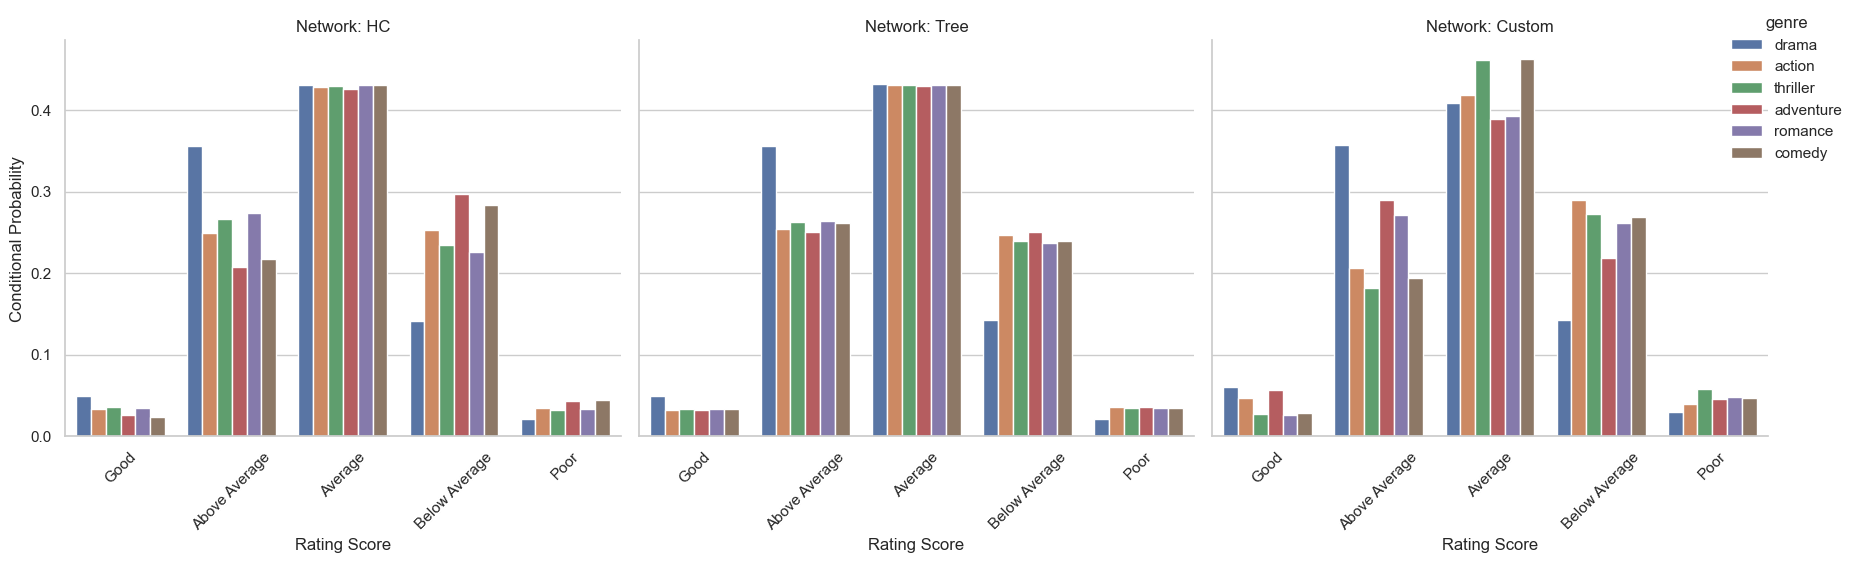

In [17]:
sns.set_theme(style="whitegrid")

g = sns.catplot(
    data=genre_conditional_df, 
    kind="bar",
    x="rating", 
    y="probability", 
    hue="genre",
    col="network",
    palette=sns.color_palette(n_colors=6),
    height=5,
    aspect=1.2,
    sharey=True
)

g.set_titles("Network: {col_name}") 
g.set_axis_labels("Rating Score", "Conditional Probability")
g.set_xticklabels(rotation=45)

sns.move_legend(g, "upper left", bbox_to_anchor=(0.9, 1))

plt.show()

### IBO vs Top Genres
In this case `adventure` and `action` are the best choices to maximize the aposteriori probability of IBO having a higher value given a genre, however in contrary with the previous findings for the rating categories for `drama` and `thriller` genres and also `romance` and `comedy` all the three networks are implying the fact that these genres are less likely to make a huge revenue .

In [18]:
IBOs = ['Below 5 Million($)', '5 to 10 Million($)',
        '10 to 25 Million($)', '25 to 50 Million($)',
        '50 to 100 Million($)', '100 to 150 Million($)',
       '150 to 300 Million($)', '300 to 500 Million($)',
       'Above 500 Million($)']
IBO_conditional_probs = []

for infer, network in zip(infers, networks):
    for genre in genres:
        q = infer.query(
            variables=['IBO'],
            evidence={genre: 'Yes'}
        )
        q = q.values
        conditional_probs = np.r_[q[-1], q[5], q[0], q[3], q[6], q[1], q[2], q[4], q[7]] # Rearranging the values from low to high
        df_temp = pd.DataFrame({'IBO': IBOs, 
                                'genre': genre, 
                                'probability': conditional_probs, 
                                'network': network})
        IBO_conditional_probs.append(df_temp)

IBO_conditional_df = pd.concat(IBO_conditional_probs, ignore_index=True)

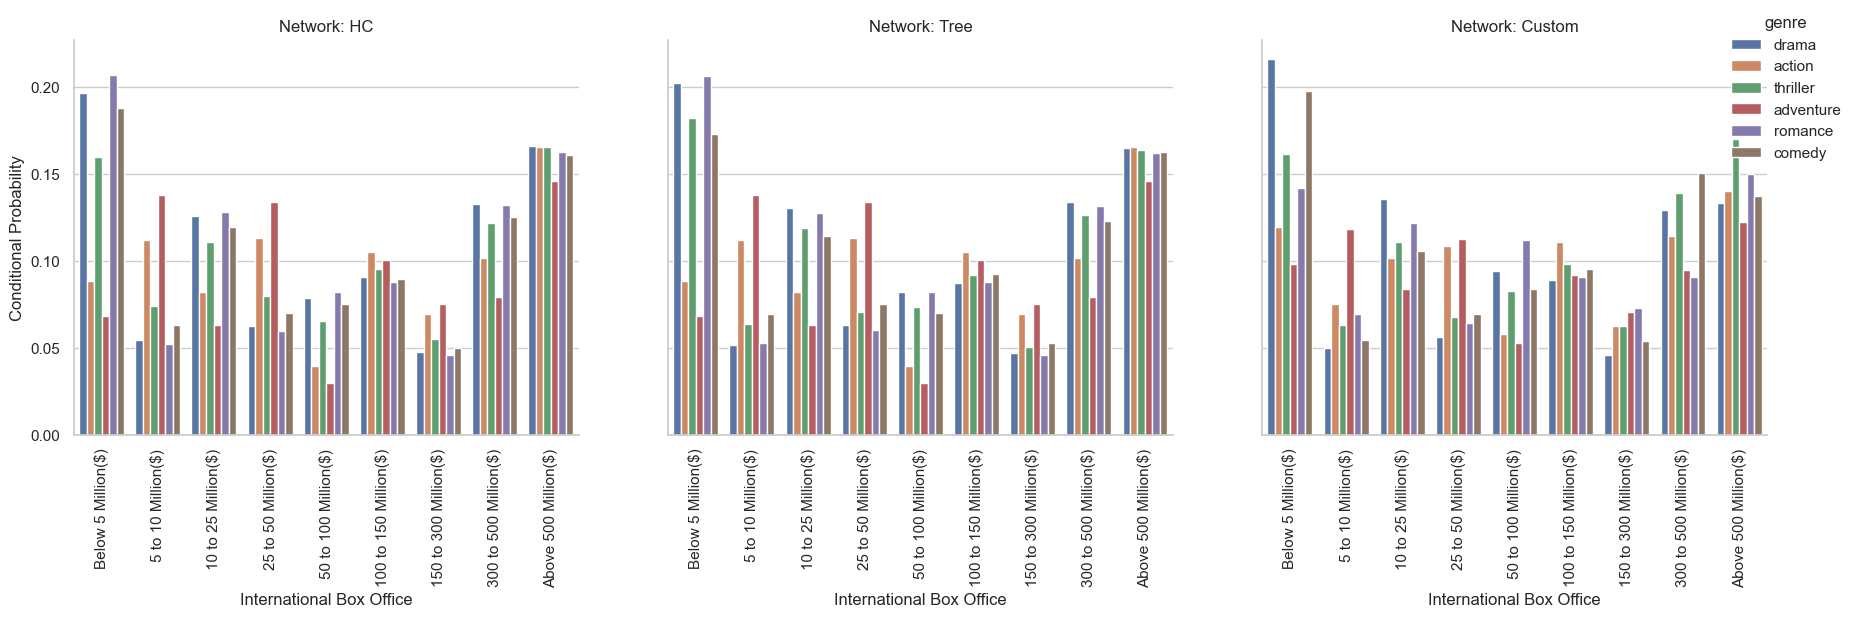

In [19]:
sns.set_theme(style="whitegrid")

g = sns.catplot(
    data=IBO_conditional_df, 
    kind="bar",
    x="IBO", 
    y="probability", 
    hue="genre",
    col="network",
    palette=sns.color_palette(n_colors=6),
    height=5,
    aspect=1.2,
    sharey=True
)

g.set_titles("Network: {col_name}") 
g.set_axis_labels("International Box Office", "Conditional Probability")
g.set_xticklabels(rotation=90)

sns.move_legend(g, "upper left", bbox_to_anchor=(0.9, 1))

plt.show()

### DBO vs Top Genres
Findings for Domestic Box Office is very close to the conditional probabilities observed for International Box Office resulting in `action` and `adventure` genres and also `comedy` genre with a bit less than the other two, to be in favor of a higher DBO in all of the networks.

In [20]:
DBOs = ['Below 10 Million($)', '10 to 25 Million($)', 
        '25 to 50 Million($)', '50 to 100 Million($)',
       '100 to 150 Million($)', '150 to 300 Million($)', 
       'Above 300 Million($)']
DBO_conditional_probs = []

for infer, network in zip(infers, networks):
    for genre in genres:
        q = infer.query(
            variables=['DBO'],
            evidence={genre: 'Yes'}
        )
        q = q.values
        conditional_probs = np.r_[q[-1], q[4], q[0], q[5], q[2], q[3], q[1]] # Rearranging the values from low to high
        df_temp = pd.DataFrame({'DBO': DBOs, 
                                'genre': genre, 
                                'probability': conditional_probs, 
                                'network': network})
        DBO_conditional_probs.append(df_temp)

DBO_conditional_df = pd.concat(DBO_conditional_probs, ignore_index=True)

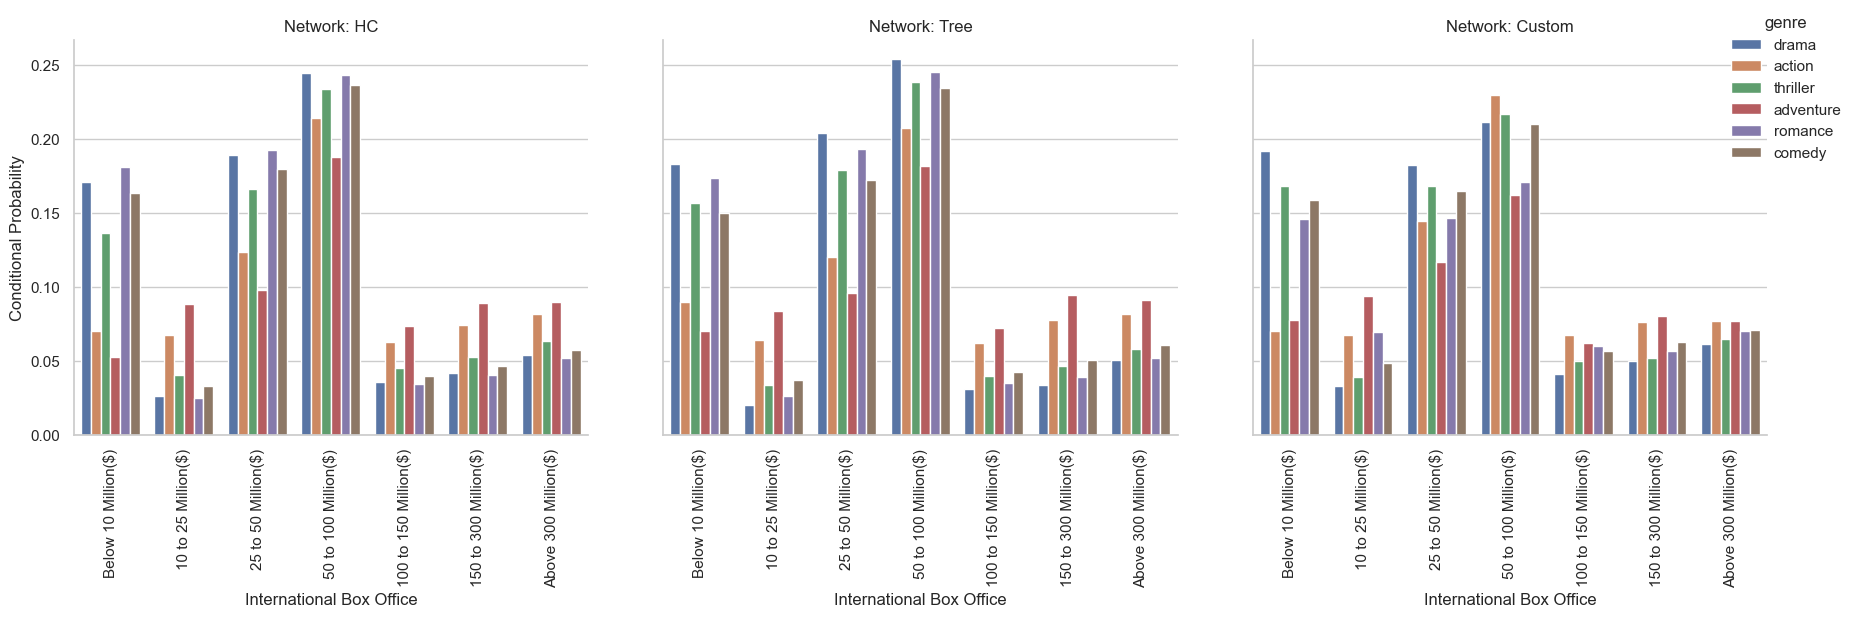

In [21]:
sns.set_theme(style="whitegrid")

g = sns.catplot(
    data=DBO_conditional_df, 
    kind="bar",
    x="DBO", 
    y="probability", 
    hue="genre",
    col="network",
    palette=sns.color_palette(n_colors=6),
    height=5,
    aspect=1.2,
    sharey=True
)

g.set_titles("Network: {col_name}") 
g.set_axis_labels("International Box Office", "Conditional Probability")
g.set_xticklabels(rotation=90)

sns.move_legend(g, "upper left", bbox_to_anchor=(0.9, 1))

plt.show()

# Rating Category Prediction

In this last part of my analysis using the Maximum Likelihood estimator for all three Discrete Bayesian Network that is cunstructed I have tried to predict the `rating` categories as one of the target values in the study. The `stochastic` of the prediction is assigned as __TRUE__ to avoid the prediction of only the category with higher probability as it was leading the prediction to never assign the rare categories to the target values in the test set because they are way less frequent compared to the common categoris. In this case the rare categories would be `Poor` and `Good`.  
The evaluation of the three networks prediction it is visible that the predictions are performing only a bit better than a random assignment to the categories (the random probability would be __0.2__ for this categorical target variable). Even this ,a bit higher accuracy, is partly a result of high number of observations available in the dataset for the frequent categories so that the prediction tends to predict more of those categories as it is using the ML estimator.

In [22]:
%%capture

X = df[['certificate', 'year', 'countries_published', 'languages_published',
       'number_of_actors', 'number_of_directors', 'source', 'drama',
       'production_method', 'has_franchise', 'runtime',
       'production_budget', 'action', 'adventure', 'comedy',
       'romance', 'thriller', 'IBO', 'DBO']]

y = df[['rating']]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1, shuffle=True, stratify=y)

fitted_hc_network = dbn_hc_model.fit(pd.concat([X_train, y_train], axis=1), estimator=MaximumLikelihoodEstimator)
y_predict = fitted_hc_network.predict(X_test, stochastic=True)

class_report = classification_report(y_test, y_predict['rating'])
conf_mat = confusion_matrix(y_test, y_predict['rating'], labels=rates)
conf_df = pd.DataFrame(conf_mat, index=rates, columns=rates)

In [23]:
print(f"Classification report for predicting the ratings using the HC network is : \n\n {class_report}")
print("-----------------------------------------------------------------------------\n")
print(f"Confusion matrix for HC network prediction : \n\n {conf_df}")

Classification report for predicting the ratings using the HC network is : 

                precision    recall  f1-score   support

Above Average       0.32      0.32      0.32        75
      Average       0.41      0.36      0.38       123
Below Average       0.19      0.22      0.20        68
         Good       0.10      0.10      0.10        10
         Poor       0.07      0.10      0.08        10

     accuracy                           0.30       286
    macro avg       0.22      0.22      0.22       286
 weighted avg       0.31      0.30      0.30       286

-----------------------------------------------------------------------------

Confusion matrix for HC network prediction : 

                Good  Above Average  Average  Below Average  Poor
Good              1              0        7              2     0
Above Average     3             24       21             23     4
Average           1             34       44             36     8
Below Average     4             13   

In [24]:
%%capture
fitted_custom_network = dbn_custom_model.fit(pd.concat([X_train, y_train], axis=1), estimator=MaximumLikelihoodEstimator)
y_predict = fitted_custom_network.predict(X_test, stochastic=True)

class_report = classification_report(y_test, y_predict['rating'])
conf_mat = confusion_matrix(y_test, y_predict['rating'], labels=rates)
conf_df = pd.DataFrame(conf_mat, index=rates, columns=rates)

In [25]:
print(f"Classification report for predicting the ratings using the Tree network is : \n\n {class_report}")
print("-----------------------------------------------------------------------------\n")
print(f"Confusion matrix for Tree network prediction : \n\n {conf_df}")

Classification report for predicting the ratings using the Tree network is : 

                precision    recall  f1-score   support

Above Average       0.32      0.29      0.31        75
      Average       0.39      0.40      0.39       123
Below Average       0.18      0.19      0.19        68
         Good       0.22      0.20      0.21        10
         Poor       0.10      0.10      0.10        10

     accuracy                           0.30       286
    macro avg       0.24      0.24      0.24       286
 weighted avg       0.30      0.30      0.30       286

-----------------------------------------------------------------------------

Confusion matrix for Tree network prediction : 

                Good  Above Average  Average  Below Average  Poor
Good              2              3        4              1     0
Above Average     3             22       35             14     1
Average           3             24       49             41     6
Below Average     1             1

In [26]:
%%capture
fitted_tree_network = dbn_tree_model.fit(pd.concat([X_train, y_train], axis=1), estimator=MaximumLikelihoodEstimator)
y_predict = fitted_tree_network.predict(X_test, stochastic=True)

class_report = classification_report(y_test, y_predict['rating'])
conf_mat = confusion_matrix(y_test, y_predict['rating'], labels=rates)
conf_df = pd.DataFrame(conf_mat, index=rates, columns=rates)

In [27]:
print(f"Classification report for predicting the ratings using the Custom network is : \n\n {class_report}")
print("-----------------------------------------------------------------------------\n")
print(f"Confusion matrix for Custom network prediction : \n\n {conf_df}")

Classification report for predicting the ratings using the Custom network is : 

                precision    recall  f1-score   support

Above Average       0.25      0.29      0.27        75
      Average       0.42      0.36      0.38       123
Below Average       0.26      0.28      0.27        68
         Good       0.00      0.00      0.00        10
         Poor       0.00      0.00      0.00        10

     accuracy                           0.30       286
    macro avg       0.19      0.19      0.18       286
 weighted avg       0.31      0.30      0.30       286

-----------------------------------------------------------------------------

Confusion matrix for Custom network prediction : 

                Good  Above Average  Average  Below Average  Poor
Good              0              1        4              5     0
Above Average     3             22       28             19     3
Average           3             43       44             28     5
Below Average     2          